In [ ]:
from google.colab import files

uploaded = files.upload()

Saving advertising.csv to advertising.csv


In [ ]:
import pandas as pd

df = pd.read_csv('advertising.csv')

print("Dataset loaded successfully!")
print("Rows and columns:", df.shape)

df.head()

Dataset loaded successfully!
Rows and columns: (200, 4)


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [ ]:
# Display basic information about the dataset

print("Dataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
display(df.describe())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB

Missing Values:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

Statistical Summary:


,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


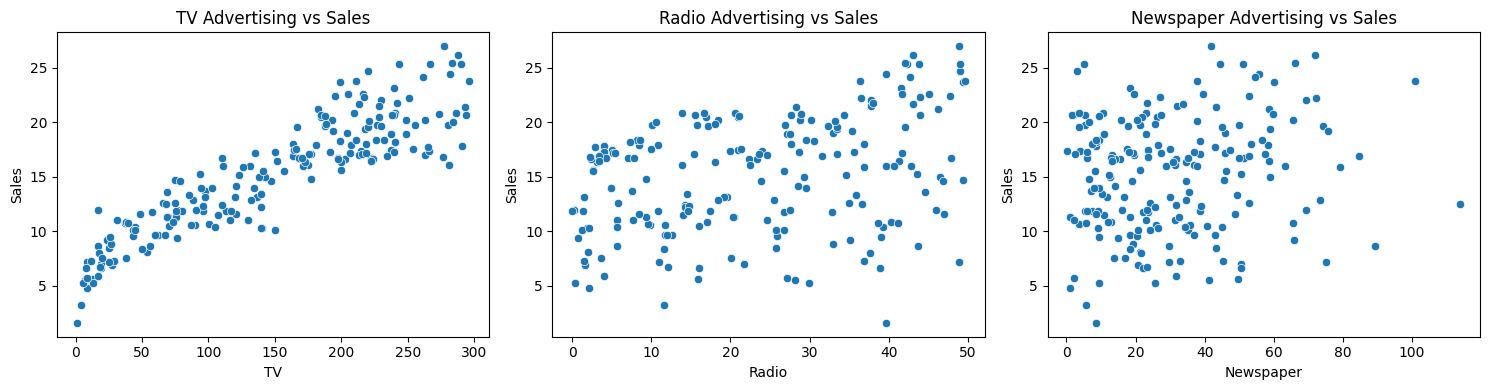

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create scatter plots for advertising channels vs sales

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
sns.scatterplot(data=df, x='TV', y='Sales')
plt.title('TV Advertising vs Sales')

plt.subplot(1, 3, 2)
sns.scatterplot(data=df, x='Radio', y='Sales')
plt.title('Radio Advertising vs Sales')

plt.subplot(1, 3, 3)
sns.scatterplot(data=df, x='Newspaper', y='Sales')
plt.title('Newspaper Advertising vs Sales')

plt.tight_layout()
plt.show()

Correlation with Sales:
Sales        1.000000
TV           0.901208
Radio        0.349631
Newspaper    0.157960
Name: Sales, dtype: float64


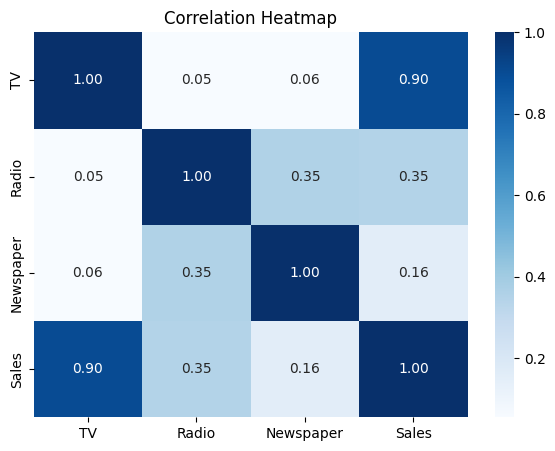

In [ ]:
# Calculate correlation between variables

correlation = df.corr(numeric_only=True)

print("Correlation with Sales:")
print(correlation['Sales'].sort_values(ascending=False))

# Visualize the correlations
plt.figure(figsize=(7, 5))
sns.heatmap(correlation, annot=True, cmap='Blues', fmt='.2f')

plt.title('Correlation Heatmap')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

# Features
X = df[['TV', 'Radio', 'Newspaper']]

# Target
y = df['Sales']

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Data split completed successfully!")
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Data split completed successfully!
Training samples: 160
Testing samples: 40


In [ ]:
from sklearn.linear_model import LinearRegression

# Create the model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [ ]:
# Make predictions
y_pred = model.predict(X_test)

print("Sales predictions generated successfully!")
print("First 10 predicted sales values:")
print(y_pred[:10])

Sales predictions generated successfully!
First 10 predicted sales values:
[17.0347724  20.40974033 23.72398873  9.27278518 21.68271879 12.56940161
 21.08119452  8.69035045 17.23701254 16.66657475]


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("========== MODEL EVALUATION ==========")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

========== MODEL EVALUATION ==========
Mean Absolute Error (MAE): 1.27
Root Mean Squared Error (RMSE): 1.71
R² Score: 0.91


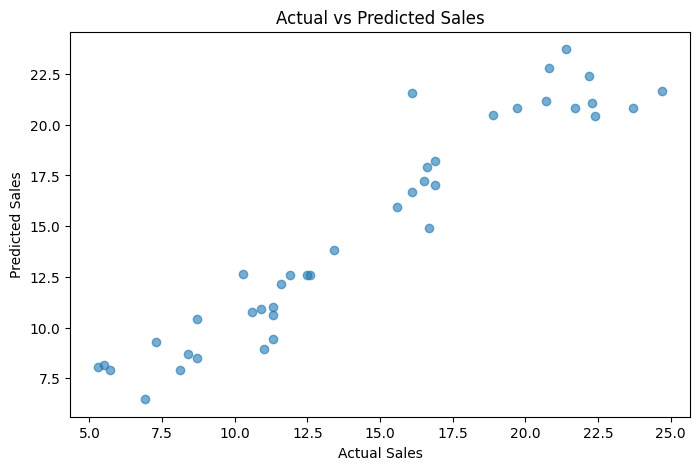

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales')

plt.show()

## Conclusion

In this project, a Linear Regression model was developed to predict sales based on advertising expenditure on TV, Radio, and Newspaper. The dataset was explored, analyzed, and divided into training and testing sets. The model was evaluated using MAE, RMSE, and R² score. The Actual vs Predicted graph was also used to visualize the model's performance.

The project demonstrates how machine learning can be used to understand the relationship between advertising expenditure and sales and make sales predictions.